# CRVSE Phase B - Ensemble rPPG - CRVSEResNet 1D (Round 3) part 2 - multichannel (3ch)

### What this notebook does

Trains 1D ResNet family (vanilla 'CRVSEResNet` + Squeeze-and-Excitation `CRVSEResNetSE`) on ensemble rPPG signals (POS + CHROM + GREEN).

**Input mode `multichannel`** - stacked `[POS, CHROM, GREEN]` as 3 independent input channels `(3, 240)`. The model learns its own implicit SQI weighting across the three algorithm outputs.

Runs **two Optuna studies** (vanilla ResNet + SE ResNet, both on the 3 stacked channels), retrains the best configuration of each on train+val, evaluates on the held-out test set, and compares the two variants.

Architecture is carried over from the POS-only ResNet round (Round 4): the data pipeline, SQI gating, and evaluation suite match the InceptionNet1D ensemble notebooks (Round 2), so results are directly comparable across rounds.

## 1. Imports and Config


In [1]:
import h5py, torch, os, optuna, json
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from collections import defaultdict, Counter
from tqdm import tqdm
from typing import Callable

#  Paths  (ensemble HDF5 files: POS + CHROM + GREEN + pre-fused ensemble)
H5_PATHS = {
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/mcd_rppg_ensemble.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_rppg_ensemble.h5",
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_phys_ensemble.h5",
    "ecg_fitness" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ecg_fitness_ensemble.h5",
}

# SQI gates per dataset
# Thresholds calibrated during preprocessing (see NB06/NB07/NB08).
# MCD-rPPG 0.10 : recalibrated (ensemble scale differs from POS-only)
# UBFC-rPPG 0.07: original threshold, clean lab conditions
# UBFC-Phys 0.05: lowered - 35fps + 1024x1024 + stress tasks lower spectral SQI
DATASET_SQI_THRESHOLDS = {
    "mcd_rppg" : 0.10,
    "ubfc_rppg" : 0.07,
    "ubfc_phys" : 0.05,
    "ecg_fitness" : 0.07,
}

# Fixed config
MODEL_NAME = "CRVSEResNet_Ensemble"
INPUT_MODE = "multichannel"
IN_CHANNELS = 3 # stacked [POS, CHROM, GREEN]
STUDY_TAG = "ens_multi" # suffix appended to each architecture's study name

HR_MIN = 40.0
HR_MAX = 180.0
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
# NOTE: this notebook runs TWO studies (vanilla ResNet + SE ResNet), so the
# effective trial budget is 2 x N_TRIALS. With MedianPruner most weak trials are
# killed at ~PRUNER_WARMUP epochs, but if the Kaggle GPU quota / 12h session is
# tight, drop N_TRIALS to 30 or run the two architectures in separate sessions.
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5

print(f"Device : {DEVICE}")
print(f"Model : {MODEL_NAME}")
print(f"Input mode : {INPUT_MODE} ({IN_CHANNELS} channels)")
print(f"Trials/study : {N_TRIALS} | Max epochs/trial : {N_EPOCHS} | 2 studies (vanilla + SE)")
print(f"Datasets : {list(H5_PATHS.keys())}")
print(f"SQI thresholds : {DATASET_SQI_THRESHOLDS}")

Device : cuda
Model : CRVSEResNet_Ensemble
Input mode : multichannel (3 channels)
Trials/study : 50 | Max epochs/trial : 50 | 2 studies (vanilla + SE)
Datasets : ['mcd_rppg', 'ubfc_rppg', 'ubfc_phys', 'ecg_fitness']
SQI thresholds : {'mcd_rppg': 0.1, 'ubfc_rppg': 0.07, 'ubfc_phys': 0.05, 'ecg_fitness': 0.07}


## 2. Window Extractor

In [2]:
def extract_windows(signals: dict, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int,
                    target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> list:
    """
    Extract sliding windows from one recording.

    Returns:
        list of dicts, each containing:
            pos_win, chrom_win, green_win, ensemble_win : (target_frames,) float32
            hr_label : scalar float, nanmean of hr_cont over the window.
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(hr_cont)
    results = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames
        hr_win = hr_cont[start:end]

        # Gate 1: NaN fraction on HR label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue

        # Gate 2: scalar HR label inside physiological range
        hr_label = float(np.nanmean(hr_win))
        if not (hr_min <= hr_label <= hr_max):
            continue

        # Process each signal channel
        win_dict = {}
        skip = False

        for key in ("pos", "chrom", "green", "ensemble"):
            sig_win = signals[key][start:end]

            # Gate 3: NaN on signal
            if np.any(np.isnan(sig_win)):
                skip = True
                break

            # Resample to fixed length
            if len(sig_win) != target_frames:
                sig_win = resample(sig_win, target_frames).astype(np.float32)

            # Gate 4: flat signal (std < 1e-6 means no pulse information)
            std = sig_win.std()
            if std < 1e-6:
                skip = True
                break

            # Z-score per window per channel
            sig_win = ((sig_win - sig_win.mean()) / std).astype(np.float32)
            win_dict[f"{key}_win"] = sig_win

        if skip:
            continue

        win_dict["hr_label"] = hr_label
        results.append(win_dict)

    return results

## 3. Index Builder

Reads all HDF5 files once and builds a flat list of window dicts. All four signal channels (POS, CHROM, GREEN, ensemble) are stored per window. SQI ggating is applied per dataset before windowing.

In [3]:
def build_index(h5_paths: dict, sqi_thresholds: dict, window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Builds flat window index from all ensemble HDF5 files.

    SQI gate: recordings with sqi_ensemble < sqi_thresholds[dataset] are skipped.
    Threshold is dataset-specific - calibrated in preprocessing NBs.

    Returns:
        samples : list of window dicts (all channels pre-computed)
        subject_keys : sorted list of unique subject keys for split.
    """
    samples = []
    subject_keys = set()
    skipped_sqi = 0

    for dataset_name, path in h5_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Not found, skipping: {path}")
            continue

        sqi_gate = sqi_thresholds.get(dataset_name, 0.07)

        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]

                    # SQI gate - skip recording before any signal read
                    sqi_ens = float(rec.attrs.get("sqi_ensemble", 1.0))
                    if sqi_ens < sqi_gate:
                        skipped_sqi += 1
                        continue

                    fps = float(rec.attrs["fps"])
                    hr_cont = rec["hr_continuous"][:]

                    # Read all four signals - stored for both study modes
                    signals = {
                        "pos" : rec["rppg_pos"][:],
                        "chrom" : rec["rppg_chrom"][:],
                        "green" : rec["rppg_green"][:],
                        "ensemble" : rec["rppg_ensemble"][:],
                    }

                    wins = extract_windows(signals, hr_cont, fps, window_sec, stride_sec,
                                           target_frames, max_nan_frac, hr_min, hr_max)
                    for w in wins:
                        w["subject_key"] = subj_key
                        w["dataset"] = dataset_name
                        samples.append(w)

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    print(f"Recordings skipped (SQI) : {skipped_sqi}")

    # Per-dataset breakdown
    ds_counts = Counter(s["dataset"] for s in samples)
    print("\nPer-dataset window counts:")
    for ds, n in sorted(ds_counts.items()):
        print(f"{ds:<15} : {n:>6} windows")

    return samples, sorted(subject_keys)

## 4. Subject-Level Train/Val/Test Split

In [4]:
def subject_split(subject_keys: list, train_frac: float = 0.7, val_frac: float = 0.15, seed: int = 42) -> tuple:
    """
    Subject-level split. No subject appears in more than one split.
    test_frac = 1 - train_frac - val_frac
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys = set(keys[:n_train])
    val_keys = set(keys[n_train : n_train + n_val])
    test_keys = set(keys[n_train + n_val:])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset Class

Assemble the input tensor from pre-built window dicts based on `input_mode`:

* `ensemble_only` -> `(1, 240)` single pre-fused quality-weighted channel
* `multichannel`  -> `(3, 240)` stacked [POS, CHROM, GREEN]

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase B ensemble rPPG -> HR estimation.

    Args:
        samples : list of window dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
        input_mode : `ensemble_only` | `multichannel` - controls which signals
                     are assembled into the input tensor.
    """
    def __init__(self, samples: list, subject_set: set, input_mode: str = "multichannel") -> None:
        self.input_mode = input_mode
        self.items = [s for s in samples if s["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows (mode={input_mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple:
        item = self.items[idx]

        if self.input_mode == "ensemble_only":
            # Shape: (1, 240) - single pre-fused channel
            signal = torch.tensor(item["ensemble_win"], dtype=torch.float32).unsqueeze(0)
        else:
            # Shape: (3, 240) - 3 independent algorithm outputs
            signal = torch.stack([
                torch.tensor(item["pos_win"],   dtype=torch.float32),
                torch.tensor(item["chrom_win"], dtype=torch.float32),
                torch.tensor(item["green_win"], dtype=torch.float32),
            ])

        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label

## 6. Model Architecture


### ResBlock with optional Squeeze-and-Excitation

In [6]:
class SEBlock1D(nn.Module):
    """
    Squeeze-and-Excitation channel attention for 1D feature maps.

    Args:
        channels : number of input/output channels
        reduction : compression ratio for the bottleneck FC (default 16)
    """
    def __init__(self, channels: int, reduction: int = 16) -> None:
        super().__init__()

        squeezed = max(channels // reduction, 4)  # floor at 4 to avoid collapse

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), # (B, C, 1) - squeeze
            nn.Flatten(), # (B, C)
            nn.Linear(channels, squeezed),
            nn.ReLU(),
            nn.Linear(squeezed, channels),
            nn.Sigmoid(), # scale in [0, 1]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)
        scale = self.se(x) # (B, C)
        return x * scale.unsqueeze(-1)   # (B, C, T) - channel rescaling


class ResBlock1D(nn.Module):
    """
    Basic 1D residual block with optional Squeeze-and-Excitation.

    Two convolutions with BN + ReLU, skip connection for gradient flow. When stride > 1 or
    channels change, the skip connection uses a 1x1 projection conv to match dimensions.

    Args:
        in_channels : input channel count
        out_channels : output channel count
        kernel_size : convolution kernel (same for both convs)
        stride : stride on first conv - use 2 for downsampling
        dropout : dropout after second BN
        use_se : whether to apply SE channel attention
        se_reduction : SE compression ratio
    """
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, stride: int = 1,
                 dropout: float = 0.1, use_se: bool = False, se_reduction: int = 16) -> None:
        super().__init__()
        padding = kernel_size // 2 # same padding - preserves T when stride=1

        # Main path
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size,
                               stride=1, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

        # SE block (optional)
        self.se = SEBlock1D(out_channels, se_reduction) if use_se else nn.Identity()

        # Skip connection - projection needed when dimensions change
        needs_proj = (in_channels != out_channels) or (stride != 1)
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )
            if needs_proj else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = self.skip(x) # (B, out_channels, T//stride)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.dropout(out)
        out = self.se(out) # channel rescaling (or identity)

        out = F.relu(out + identity) # residual addition
        return out 

### CRVSEResNet - vanilla ResNet1D

In [7]:
class CRVSEResNet(nn.Module):
    """
    1D ResNet for rPPG -> HR estimation.

    Args:
        in_channels : input channels (1 for ensemble_only, 3 for multichannel)
        base_channels : Stage 1 channel width - doubles each stage
        n_blocks_per_stage : residual blocks per stage
        n_stages : number of stages including downsampling (2 or 3)
        kernel_size : conv kernel throughout residual blocks
        dropout : dropout inside each ResBlock
        hr_min / hr_max : physiological output clamp
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 32, n_blocks_per_stage: int = 2, n_stages: int = 2,
                 kernel_size: int = 3, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max

        #  Stem
        # Broad kernel captures initial pulse morphology features.
        # No downsampling here - preserve full resolution entry.
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
        )

        # Residual Stages
        stages = []
        current_ch = base_channels

        for stage_idx in range(n_stages):
            out_ch = base_channels * (2 ** stage_idx) # 32 -> 64 -> 128
            stride = 1 if stage_idx == 0 else 2 # only downsample from stage 2+

            for block_idx in range(n_blocks_per_stage):
                stages.append(ResBlock1D(
                    in_channels  = current_ch,
                    out_channels = out_ch,
                    kernel_size  = kernel_size,
                    stride = stride if block_idx == 0 else 1,
                    dropout = dropout,
                    use_se = False,
                ))
                current_ch = out_ch

        self.stages = nn.Sequential(*stages)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(current_ch, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.stem(x) # (B, base_channels, 240)
        out = self.stages(out) # (B, final_channels, T//stride_product)
        out = out.mean(dim=-1) # (B, final_channels) - GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### CRVSEResNetSE - ResNet1D + Squeeze-and-Excitation

In [8]:
class CRVSEResNetSE(nn.Module):
    """
    1D ResNet + Squeeze-and-Excitation for rPPG -> HR estimation.

    Identical to CRVSEResNet but every ResBlock applies SE channel attention after
    the second convolution. The SE block learns to recalibrate which feature channels
    are most informative for the current input - for rPPG this means upweighting channels
    that encode pulse-frequency information and suppressing noise.

    Additional args vs CRVSEResNet:
        se_reduction : SE bottleneck compression ratio (default 16)
                       smaller = more expressive but more parameters
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 32, n_blocks_per_stage: int = 2, n_stages: int = 2,
                 kernel_size: int = 3, dropout: float = 0.2, se_reduction: int = 16, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()

        self.hr_min = hr_min
        self.hr_max = hr_max

        # Stem
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
        )

        #  Residual Stages with SE
        stages = []
        current_ch = base_channels

        for stage_idx in range(n_stages):
            out_ch = base_channels * (2 ** stage_idx)
            stride = 1 if stage_idx == 0 else 2

            for block_idx in range(n_blocks_per_stage):
                stages.append(ResBlock1D(
                    in_channels  = current_ch,
                    out_channels = out_ch,
                    kernel_size  = kernel_size,
                    stride = stride if block_idx == 0 else 1,
                    dropout = dropout,
                    use_se = True,
                    se_reduction = se_reduction,
                ))
                current_ch = out_ch

        self.stages = nn.Sequential(*stages)

        # Regression Head
        self.head = nn.Sequential(
            nn.Linear(current_ch, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.stem(x)
        out = self.stages(out)
        out = out.mean(dim=-1)
        out = self.head(out).squeeze(-1)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out 

In [9]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Sanity check - both variants at the input channel count for this notebook
dummy = torch.randn(32, IN_CHANNELS, TARGET_FRAMES)

configs = [
    ("CRVSEResNet", CRVSEResNet(
        in_channels=IN_CHANNELS, base_channels=32,
        n_blocks_per_stage=2, n_stages=2,
        kernel_size=3, dropout=0.2,
    )),
    ("CRVSEResNetSE", CRVSEResNetSE(
        in_channels=IN_CHANNELS, base_channels=32,
        n_blocks_per_stage=2, n_stages=2,
        kernel_size=3, dropout=0.2, se_reduction=16,
    )),
]

print(f"Input shape : {tuple(dummy.shape)}  (mode={INPUT_MODE})")
print(f"{'Model':<20} {'Output':>14} {'Params':>12}")
print("-" * 50)
for name, model in configs:
    with torch.no_grad():
        out = model(dummy)
    print(f"{name:<20} {str(tuple(out.shape)):>14} {count_parameters(model):>12,}")

Input shape : (32, 3, 240)  (mode=multichannel)
Model                        Output       Params
--------------------------------------------------
CRVSEResNet                   (32,)       61,089
CRVSEResNetSE                 (32,)       62,833


## 7. Data Preparation

In [10]:
all_samples, all_subject_keys = build_index(
    h5_paths = H5_PATHS,
    sqi_thresholds = DATASET_SQI_THRESHOLDS,
    window_sec = WINDOW_SEC,
    stride_sec = STRIDE_SEC,
    target_frames = TARGET_FRAMES,
    max_nan_frac = MAX_NAN_FRAC,
    hr_min = HR_MIN,
    hr_max = HR_MAX,
)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.7, val_frac=0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys, input_mode=INPUT_MODE)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys, input_mode=INPUT_MODE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Total windows extracted : 19052
Total unique subjects : 479
Recordings skipped (SQI) : 246

Per-dataset window counts:
ecg_fitness     :    882 windows
mcd_rppg        :  11283 windows
ubfc_phys       :   6239 windows
ubfc_rppg       :    648 windows
Train subjects : 335
Val subjects : 71
Test subjects : 73

Train dataset:
Dataset size: 12954 windows (mode=multichannel)
Val dataset:
Dataset size: 2992 windows (mode=multichannel)
Test dataset:
Dataset size: 3106 windows (mode=multichannel)


## 8. Evaluation Functions

In [11]:
def compute_subject_level_metrics(preds: np.ndarray, labels: np.ndarray, subject_ids: list) -> dict:
    """
    Aggregate window predictions per subject (mean), then compute metrics across subjects.
    Subject-level MAE is the standard rPPG benchmark metric.
    """
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)

    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])

    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")

    return {
        "subj_mae" : mae,
        "subj_rmse" : rmse,
        "subj_r" : r,
        "ba_bias" : ba_bias,
        "ba_loa_lo" : ba_bias - 1.96*ba_sd,
        "ba_loa_hi" : ba_bias + 1.96*ba_sd,
        "n_subjects" : len(subj_pred_mean),
    }


def coverage_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    abs_err = np.abs(preds - labels)
    for threshold in [5, 10, 15]:
        pct = float(np.mean(abs_err < threshold) * 100)
        print(f"|error| < {threshold:>2} BPM : {pct:.1f}% of windows")


def per_dataset_metrics(preds: np.ndarray, labels: np.ndarray, dataset_ids: list) -> None:
    datasets = sorted(set(dataset_ids))
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")

    for ds in datasets:
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _ = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100, 180, "tachycardia/exercise")]

    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")

    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        mae = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        print(f"{label:<22} {mask.sum():>5} {mae:>8.2f} {rmse:>8.2f}")


def full_evaluation(preds: np.ndarray, labels: np.ndarray, subject_ids: list, dataset_ids: list, model_name: str = "Model") -> None:
    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")

    # Window-level
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    ss_res = np.sum(diff ** 2)
    ss_tot = np.sum((labels - labels.mean()) ** 2)
    r2 = float(1 - ss_res / ss_tot)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96 * ba_sd
    loa_hi = ba_bias + 1.96 * ba_sd

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f}  (p={pval:.4f})")
    print(f"R2 : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{loa_lo:.2f}, {loa_hi:.2f}] BPM")

    # Coverage
    print()
    coverage_metrics(preds, labels)

    # Subject-level
    compute_subject_level_metrics(preds, labels, subject_ids)

    # Per-dataset
    per_dataset_metrics(preds, labels, dataset_ids)

    # HR-stratified
    hr_stratified_metrics(preds, labels) 

## 9. Shared Optuna Objective Factory

In [12]:
def make_progress_callback(name: str) -> Callable:
    """Per-trial visible output line for a given architecture name."""
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM  "
        best = study.best_value
        p = trial.params
        print(
            f"[{name}] Trial {trial.number:>3} | "
            f"val MAE : {status} | "
            f"best : {best:.3f} BPM | "
            f"lr={p.get('lr','?'):.1e}  "
            f"wd={p.get('weight_decay','?'):.1e}  "
            f"drop={p.get('dropout','?'):.2f}  "
            f"base_ch={p.get('base_channels','?')}  "
            f"stages={p.get('n_stages','?')}  "
            f"blocks={p.get('n_blocks_per_stage','?')}"
        )
    return progress_callback


def make_objective(model_class: type, search_space: Callable[[optuna.Trial], dict],
                   in_channels: int, train_loader: DataLoader, val_loader: DataLoader) -> Callable[[optuna.Trial], float]:
    """
    Factory returning an Optuna objective bound to a model class, its search space,
    the input channel count, and the train/val DataLoaders.
    """
    def objective(trial: optuna.Trial) -> float:
        # Tier 1 - regularisation & optimiser
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 - model-specific architecture params
        arch_kwargs = search_space(trial)

        model = model_class(
            in_channels = in_channels,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX,
            **arch_kwargs,
        ).to(DEVICE)

        loss_fn = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

        # tqdm epoch bar - live progress inside every trial
        epoch_bar = tqdm(range(1, N_EPOCHS + 1),
                         desc=f"Trial {trial.number:>3}", unit="ep", leave=False)

        for epoch in epoch_bar:
            # Train
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(signals), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate
            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    total_mae += torch.mean(torch.abs(model(signals) - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            epoch_bar.set_postfix({"val_mae": f"{val_mae:.2f}"})
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective


def run_study(name: str, model_class: type, search_space: Callable) -> optuna.Study:
    """Create + run one Optuna study for a single architecture in this input mode."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
        study_name = name,
    )
    print(f"\nStarting study: {name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each | input_mode={INPUT_MODE} ({IN_CHANNELS}ch)")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "-" * 70)

    study.optimize(
        make_objective(model_class, search_space, IN_CHANNELS, train_loader, val_loader),
        n_trials = N_TRIALS,
        callbacks = [make_progress_callback(name)],
        show_progress_bar = False,
    )

    n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

    print(f"\n{'='*50}")
    print(f"{name} - STUDY COMPLETE")
    print(f"{'='*50}")
    print(f"Best val MAE : {study.best_value:.2f} BPM")
    print(f"Best trial : #{study.best_trial.number}")
    print(f"Completed : {n_complete} | Pruned : {n_pruned}")
    print(f"\n  Best hyperparameters:")
    for key, value in study.best_params.items():
        print(f"{key:<20} : {value}")

    return study

In [13]:
# Architecture-specific search spaces
def search_space_resnet(trial: optuna.Trial) -> dict:
    return {
        "base_channels" : trial.suggest_categorical("base_channels", [16, 32, 64]),
        "n_blocks_per_stage" : trial.suggest_int("n_blocks_per_stage", 1, 3),
        "n_stages" : trial.suggest_categorical("n_stages", [2, 3]),
        "kernel_size" : trial.suggest_categorical("kernel_size", [3, 5, 7]),
    }

def search_space_resnet_se(trial: optuna.Trial) -> dict:
    return {
        "base_channels" : trial.suggest_categorical("base_channels", [16, 32, 64]),
        "n_blocks_per_stage" : trial.suggest_int("n_blocks_per_stage", 1, 3),
        "n_stages" : trial.suggest_categorical("n_stages", [2, 3]),
        "kernel_size" : trial.suggest_categorical("kernel_size", [3, 5, 7]),
        "se_reduction" : trial.suggest_categorical("se_reduction", [8, 16, 32]),
    }

## 10. Optuna Hyperparameter Studies


In [14]:
# Study A - CRVSEResNet (vanilla)
print("=" * 50)
print(f"ROUND 3A - CRVSEResNet | {INPUT_MODE}")
print("=" * 50)
study_resnet = run_study(
    f"crvse_resnet__{STUDY_TAG}",
    CRVSEResNet,
    search_space_resnet,
)

ROUND 3A - CRVSEResNet | multichannel

Starting study: crvse_resnet__ens_multi
50 trials | up to 50 epochs each | input_mode=multichannel (3ch)
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ----------------------------------------------------------------------


[crvse_resnet__ens_multi] Trial   0 | val MAE : 8.460 BPM   | best : 8.460 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.32  base_ch=16  stages=3  blocks=3


[crvse_resnet__ens_multi] Trial   1 | val MAE : 8.173 BPM   | best : 8.173 BPM | lr=1.6e-04  wd=3.5e-05  drop=0.16  base_ch=16  stages=3  blocks=2


[crvse_resnet__ens_multi] Trial   2 | val MAE : 8.493 BPM   | best : 8.173 BPM | lr=1.6e-04  wd=3.5e-04  drop=0.28  base_ch=16  stages=2  blocks=3


[crvse_resnet__ens_multi] Trial   3 | val MAE : 8.473 BPM   | best : 8.173 BPM | lr=2.8e-04  wd=2.3e-05  drop=0.25  base_ch=16  stages=3  blocks=1


...

[crvse_resnet__ens_multi] Trial  45 | val MAE : PRUNED       | best : 7.801 BPM | lr=7.9e-04  wd=1.2e-03  drop=0.18  base_ch=16  stages=3  blocks=2


[crvse_resnet__ens_multi] Trial  46 | val MAE : 8.224 BPM   | best : 7.801 BPM | lr=4.6e-04  wd=2.9e-04  drop=0.16  base_ch=32  stages=2  blocks=3


[crvse_resnet__ens_multi] Trial  47 | val MAE : 8.023 BPM   | best : 7.801 BPM | lr=8.7e-04  wd=7.8e-04  drop=0.12  base_ch=32  stages=3  blocks=3


[crvse_resnet__ens_multi] Trial  48 | val MAE : 8.070 BPM   | best : 7.801 BPM | lr=8.4e-04  wd=2.2e-04  drop=0.12  base_ch=64  stages=3  blocks=2


[crvse_resnet__ens_multi] Trial  49 | val MAE : PRUNED       | best : 7.801 BPM | lr=8.8e-04  wd=6.7e-04  drop=0.10  base_ch=32  stages=3  blocks=2

crvse_resnet__ens_multi - STUDY COMPLETE
Best val MAE : 7.80 BPM
Best trial : #32
Completed : 26 | Pruned : 24

  Best hyperparameters:
lr                   : 0.0005168175404869307
weight_decay         : 0.0013027322362976677
dropout              : 0.14836172935176925
huber_delta          : 3.283775139410618
base_channels        : 32
n_blocks_per_stage   : 3
n_stages             : 3
kernel_size          : 7


In [15]:
# Study B - CRVSEResNetSE (Squeeze-and-Excitation)
print("=" * 50)
print(f"ROUND 3B - CRVSEResNetSE | {INPUT_MODE}")
print("=" * 50)
study_resnet_se = run_study(
    f"crvse_resnet_se__{STUDY_TAG}",
    CRVSEResNetSE,
    search_space_resnet_se,
)

ROUND 3B - CRVSEResNetSE | multichannel

Starting study: crvse_resnet_se__ens_multi
50 trials | up to 50 epochs each | input_mode=multichannel (3ch)
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ----------------------------------------------------------------------


[crvse_resnet_se__ens_multi] Trial   0 | val MAE : 8.574 BPM   | best : 8.574 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.32  base_ch=16  stages=3  blocks=3


[crvse_resnet_se__ens_multi] Trial   1 | val MAE : 7.952 BPM   | best : 7.952 BPM | lr=2.0e-04  wd=3.8e-04  drop=0.23  base_ch=16  stages=3  blocks=2


[crvse_resnet_se__ens_multi] Trial   2 | val MAE : 8.643 BPM   | best : 7.952 BPM | lr=1.2e-04  wd=7.0e-03  drop=0.39  base_ch=64  stages=3  blocks=2


[crvse_resnet_se__ens_multi] Trial   3 | val MAE : 8.116 BPM   | best : 7.952 BPM | lr=3.5e-04  wd=3.6e-05  drop=0.39  base_ch=16  stages=3  blocks=3


...

[crvse_resnet_se__ens_multi] Trial  45 | val MAE : PRUNED       | best : 7.208 BPM | lr=3.2e-04  wd=4.6e-04  drop=0.11  base_ch=64  stages=3  blocks=3


[crvse_resnet_se__ens_multi] Trial  46 | val MAE : PRUNED       | best : 7.208 BPM | lr=3.6e-04  wd=1.1e-03  drop=0.10  base_ch=64  stages=2  blocks=3


[crvse_resnet_se__ens_multi] Trial  47 | val MAE : PRUNED       | best : 7.208 BPM | lr=3.9e-04  wd=2.0e-03  drop=0.14  base_ch=16  stages=2  blocks=3


[crvse_resnet_se__ens_multi] Trial  48 | val MAE : PRUNED       | best : 7.208 BPM | lr=2.2e-04  wd=3.9e-04  drop=0.11  base_ch=64  stages=3  blocks=1


[crvse_resnet_se__ens_multi] Trial  49 | val MAE : 7.564 BPM   | best : 7.208 BPM | lr=5.2e-04  wd=4.1e-03  drop=0.17  base_ch=32  stages=2  blocks=3

crvse_resnet_se__ens_multi - STUDY COMPLETE
Best val MAE : 7.21 BPM
Best trial : #12
Completed : 20 | Pruned : 30

  Best hyperparameters:
lr                   : 0.0005661922024673373
weight_decay         : 0.001466813622010435
dropout              : 0.18224599741806305
huber_delta          : 3.8959045984023817
base_channels        : 64
n_blocks_per_stage   : 3
n_stages             : 2
kernel_size          : 7
se_reduction         : 32


## 11. Study Visualisations

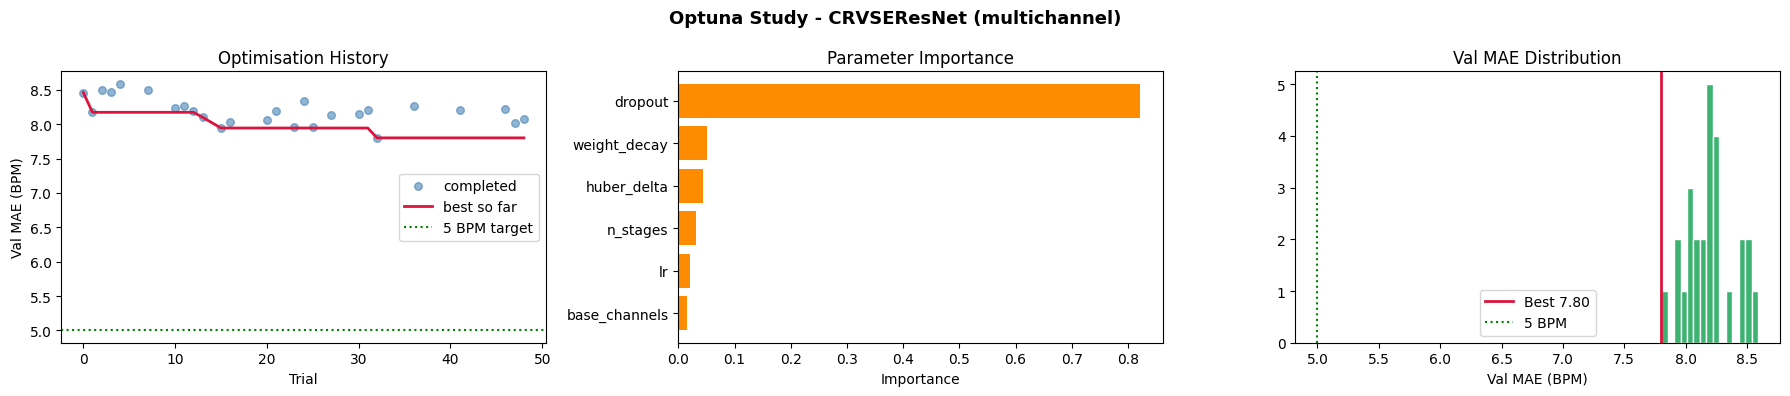

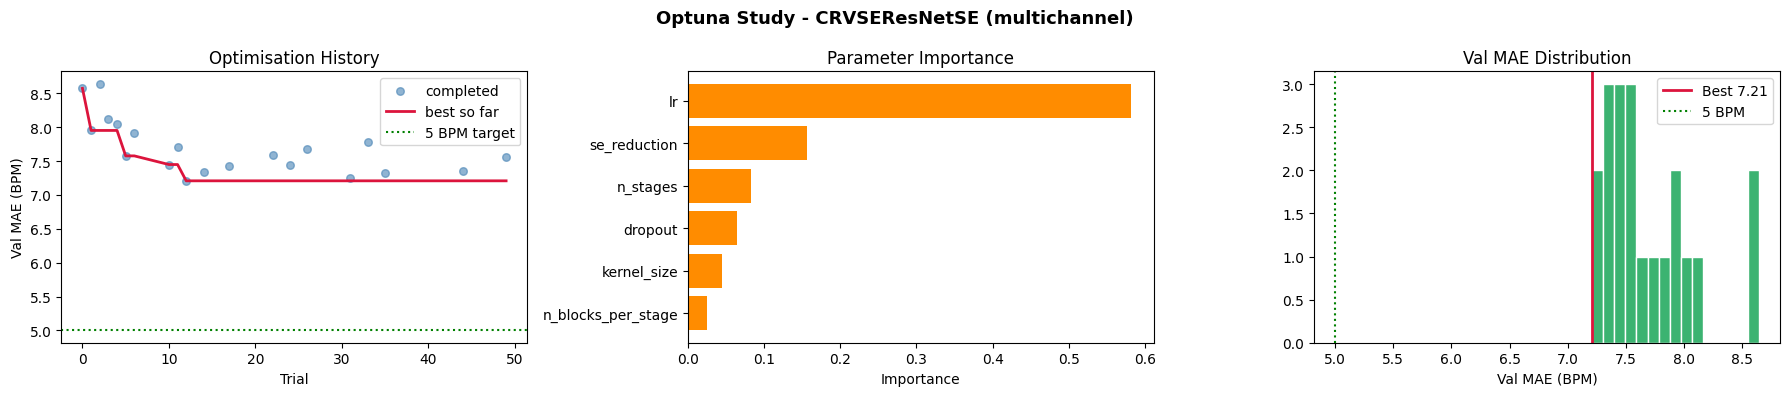

In [16]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Optuna Study - {arch_name} ({INPUT_MODE})", fontweight="bold", fontsize=13)

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        params, imps = zip(*list(importances.items())[:6])
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val MAE (BPM)"); axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_{arch_name.lower()}_{STUDY_TAG}.png", dpi=150, bbox_inches="tight")
    plt.show()


# Plot both ResNet studies
for arch_name, study in [("CRVSEResNet", study_resnet), ("CRVSEResNetSE", study_resnet_se)]:
    plot_study(study, arch_name)

## 12. Final Training on Best Configuration

Each architecture is retrained on train + val combined using its winning hyperparameters,
then evaluated on the held-out test set.

In [17]:
def retrain_best(name: str, model_class: type, study: optuna.Study, arch_keys: list, save_path: str) -> nn.Module:
    """Retrain best trial config on train+val, save checkpoint. Returns the trained model."""
    p = study.best_params
    best_n_epochs = study.best_trial.last_step

    print(f"\n{'='*50}")
    print(f"Retraining {name} ({INPUT_MODE})")
    print(f"Best trial : #{study.best_trial.number} | best val MAE : {study.best_value:.2f} BPM")
    print(f"Epochs to retrain : {best_n_epochs}")
    print(f"{'='*50}")

    arch_kwargs = {key: p[key] for key in arch_keys if key in p}

    model = model_class(
        in_channels = IN_CHANNELS,
        dropout = p["dropout"],
        hr_min = HR_MIN,
        hr_max = HR_MAX,
        **arch_kwargs,
    ).to(DEVICE)

    full_ds = CRVSEDataset(all_samples, train_keys | val_keys, input_mode=INPUT_MODE)
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    print(f"Full train set : {len(full_ds)} windows")

    loss_fn = nn.HuberLoss(delta=p["huber_delta"])
    optimizer = AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

    epoch_bar = tqdm(range(1, best_n_epochs + 1), desc=f"Training {name}", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(signals), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

    torch.save({
        "input_mode": INPUT_MODE,
        "in_channels": IN_CHANNELS,
        "best_params": p,
        "best_n_epochs": best_n_epochs,
        "best_val_mae": study.best_value,
        "model_state": model.state_dict(),
    }, save_path)
    print(f"Saved -> {save_path}")

    return model


# Architecture keys per model
RESNET_ARCH_KEYS = ["base_channels", "n_blocks_per_stage", "n_stages", "kernel_size"]
RESNET_SE_ARCH_KEYS = ["base_channels", "n_blocks_per_stage", "n_stages", "kernel_size", "se_reduction"]

# Retrain both
model_resnet = retrain_best(
    "CRVSEResNet", CRVSEResNet, study_resnet, RESNET_ARCH_KEYS,
    f"{MODEL_NAME}_resnet_{INPUT_MODE}_best.pt",
)
model_resnet_se = retrain_best(
    "CRVSEResNetSE", CRVSEResNetSE, study_resnet_se, RESNET_SE_ARCH_KEYS,
    f"{MODEL_NAME}_resnet_se_{INPUT_MODE}_best.pt",
)


Retraining CRVSEResNet (multichannel)
Best trial : #32 | best val MAE : 7.80 BPM
Epochs to retrain : 50
Dataset size: 15946 windows (mode=multichannel)
Full train set : 15946 windows


Training CRVSEResNet: 100%|██████████| 50/50 [05:45<00:00,  6.92s/epoch, loss=26.590]


Saved -> CRVSEResNet_Ensemble_resnet_multichannel_best.pt

Retraining CRVSEResNetSE (multichannel)
Best trial : #12 | best val MAE : 7.21 BPM
Epochs to retrain : 50
Dataset size: 15946 windows (mode=multichannel)
Full train set : 15946 windows


Training CRVSEResNetSE: 100%|██████████| 50/50 [06:39<00:00,  7.99s/epoch, loss=30.428]

Saved -> CRVSEResNet_Ensemble_resnet_se_multichannel_best.pt


## 13. Full Evaluation - both variants on test set

In [18]:
def collect_predictions(model: nn.Module, loader: DataLoader, ds: CRVSEDataset) -> tuple:
    """Collect predictions, labels, subject_ids, dataset_ids from a loader."""
    model.eval()
    preds_list, labels_list = [], []

    with torch.inference_mode():
        for signals, labels in loader:
            preds = model(signals.to(DEVICE)).cpu().numpy()
            preds_list.extend(preds.tolist())
            labels_list.extend(labels.numpy().tolist())

    subject_ids = [ds.items[i]["subject_key"] for i in range(len(ds))]
    dataset_ids = [ds.items[i]["dataset"] for i in range(len(ds))]

    return (
        np.array(preds_list,  dtype=np.float32),
        np.array(labels_list, dtype=np.float32),
        subject_ids,
        dataset_ids,
    )


results = {}

for name, model in [("CRVSEResNet", model_resnet), ("CRVSEResNetSE", model_resnet_se)]:
    preds, labels, subj_ids, ds_ids = collect_predictions(model, test_loader, test_ds)
    full_evaluation(preds=preds, labels=labels, subject_ids=subj_ids, dataset_ids=ds_ids,
                    model_name=f"{name} - {INPUT_MODE}")
    results[name] = {"preds": preds, "labels": labels, "subj": subj_ids, "ds": ds_ids}


FULL EVALUATION - CRVSEResNet - multichannel

Window-level (n=3106 windows):
MAE : 8.08 BPM
RMSE : 12.07 BPM
MAPE : 9.46 %
Pearson r : 0.7031  (p=0.0000)
R2 : 0.4586
BA bias : -2.78 BPM
BA LoA : [-25.80, 20.24] BPM

|error| <  5 BPM : 48.8% of windows
|error| < 10 BPM : 71.4% of windows
|error| < 15 BPM : 85.0% of windows

Subject-level metrics (n=52 subjects):
MAE : 5.22 BPM
RMSE : 8.65 BPM
r : 0.8624
BA bias: -2.99 BPM
BA LoA : [-18.89, 12.91] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
ecg_fitness       278    21.33    27.44   0.3505
mcd_rppg         2094     6.29     8.51   0.8055
ubfc_phys         658     8.55    11.65   0.1973
ubfc_rppg          76     4.58     5.65   0.9710

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          370     7.64    11.27
normal low              1657     5.72     7.81
normal high      

## 14. Round 3 - ResNet ensemble comparison


In [19]:
def resnet_comparison(results: dict) -> str:
    """Print Round 3 ResNet comparison table and return the name of the best model."""
    print("\n" + "=" * 72)
    print(f"ROUND 3 - ResNet VARIANTS COMPARISON | input_mode = {INPUT_MODE}")
    print("=" * 72)

    rows = {}
    for name, r in results.items():
        diff = r["preds"] - r["labels"]
        mae = float(np.mean(np.abs(diff)))
        rmse = float(np.sqrt(np.mean(diff ** 2)))
        pearr, _ = stats.pearsonr(r["preds"], r["labels"])
        r2 = float(1 - np.sum(diff**2) / np.sum((r["labels"] - r["labels"].mean())**2))
        ba_bias = float(diff.mean())
        cov5 = float(np.mean(np.abs(diff) < 5) * 100)

        # subject-level MAE (the headline metric)
        subj_p = defaultdict(list); subj_l = defaultdict(list)
        for p, l, s in zip(r["preds"], r["labels"], r["subj"]):
            subj_p[s].append(p); subj_l[s].append(l)
        sp = np.array([np.mean(v) for v in subj_p.values()])
        sl = np.array([np.mean(v) for v in subj_l.values()])
        subj_mae = float(np.mean(np.abs(sp - sl)))

        rows[name] = dict(mae=mae, subj_mae=subj_mae, rmse=rmse, r=float(pearr),
                          r2=r2, ba_bias=ba_bias, cov5=cov5)

    hdr = f"{'Model':<18} {'win MAE':>8} {'subj MAE':>9} {'RMSE':>7} {'r':>7} {'R2':>7} {'BA bias':>8} {'<5BPM%':>8}"
    print(hdr)
    print("-" * len(hdr))
    for name, m in rows.items():
        print(f"{name:<18} {m['mae']:>8.2f} {m['subj_mae']:>9.2f} {m['rmse']:>7.2f} "
              f"{m['r']:>7.4f} {m['r2']:>7.4f} {m['ba_bias']:>8.2f} {m['cov5']:>7.1f}%")

    best_name = min(rows, key=lambda n: rows[n]["subj_mae"])
    print(f"\nBest ({INPUT_MODE}) : {best_name} - subject MAE {rows[best_name]['subj_mae']:.2f} BPM")
    return best_name, rows


best_resnet, comparison_rows = resnet_comparison(results)

# Save best params + headline metrics for cross-notebook reference
summary = {
    "input_mode": INPUT_MODE,
    "in_channels": IN_CHANNELS,
    "best_variant": best_resnet,
    "variants": {},
}
for name, study in [("CRVSEResNet", study_resnet), ("CRVSEResNetSE", study_resnet_se)]:
    summary["variants"][name] = {
        "best_val_mae": float(study.best_value),
        "best_trial": int(study.best_trial.number),
        "best_n_epochs": int(study.best_trial.last_step),
        "best_params": study.best_params,
        "test_subj_mae": float(comparison_rows[name]["subj_mae"]),
        "test_window_mae": float(comparison_rows[name]["mae"]),
        "test_r": float(comparison_rows[name]["r"]),
    }

params_file = f"{MODEL_NAME}_{INPUT_MODE}_best_params.json"
with open(params_file, "w") as f:
    json.dump(summary, f, indent=2)
print(f"\nParams -> {params_file}")


ROUND 3 - ResNet VARIANTS COMPARISON | input_mode = multichannel
Model               win MAE  subj MAE    RMSE       r      R2  BA bias   <5BPM%
-------------------------------------------------------------------------------
CRVSEResNet            8.08      5.22   12.07  0.7031  0.4586    -2.78    48.8%
CRVSEResNetSE          7.78      5.21   11.65  0.7470  0.4958    -3.98    50.8%

Best (multichannel) : CRVSEResNetSE - subject MAE 5.21 BPM

Params -> CRVSEResNet_Ensemble_multichannel_best_params.json
